<a href="https://colab.research.google.com/github/YOUR_GITHUB_USERNAME/YOUR_REPO/blob/main/notebooks/01_cv_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nexar Collision Prediction — Notebook 01: Data Preparation

**Phase:** Data acquisition → analysis-ready frame dataset
**Runtime target:** Google Colab **free tier** (CPU runtime is enough; no GPU needed for this notebook)

---

## What this notebook does

This notebook takes the `nexar-ai/nexar_collision_prediction` dataset from a remote Hugging Face
repository and turns it into a **clean, indexed, model-ready image dataset on disk**, plus a small
set of CSV/JSON "contract" files that every downstream notebook reads instead of recomputing.

| § | Stage | Key artifact produced |
|---|-------|----------------------|
| 0 | Environment & dependencies | — |
| 1 | Mount Drive, define all constants | folder skeleton |
| 2 | Download (full or subset) | `data/cv/nexar_collision_prediction/` |
| 3 | Exploratory analysis of metadata | `exploration_summary.json` |
| 4 | Video probing (FPS, duration, corruption) | `video_metadata.csv` |
| 5 | Frame extraction @ 2 FPS | `frames_raw/` + `frame_extraction_log.csv` |
| 6 | Resize / colour / normalization stats | `frames_processed/` + `dataset_mean_std.json` + `processed_frames_log.csv` |
| 7 | Master table + leakage-free train/val split | `dataset_master.csv`, `train_split.csv`, `validation_split.csv` |

## Three design principles this notebook follows

1. **Probe once, reuse forever.** Decoding video is the most expensive thing we do. Every expensive
   operation writes its result to a CSV, and every later step *reads that CSV* instead of touching
   the video files again.
2. **Resumable by default.** Colab free-tier sessions disconnect. Every long loop (§4, §5, §6)
   records completed work to an append-only log and skips it on rerun. Losing a session costs you
   minutes, not hours. Set the `FORCE_*` flags in §1.2 to start any stage over from scratch.
3. **Split by video, never by frame.** Consecutive frames from one clip are near-duplicates. This is
   the single most important decision in the notebook and it is enforced with an assertion in §7.4.

## How to open this in Colab

A Colab URL has to point at a file Colab can *reach*, so you need to host this notebook first.
Pick whichever fits your workflow:

- **From Google Drive (easiest):** upload the `.ipynb` to Drive → right-click → *Open with* →
  *Google Colaboratory*. Colab then shows a permanent URL of the form
  `https://colab.research.google.com/drive/<FILE_ID>`. Paste that `<FILE_ID>` into the badge at the
  top of this cell to make the badge work for you and your teammates.
- **From GitHub:** push the notebook to a repo, then edit the badge link above, replacing
  `YOUR_GITHUB_USERNAME/YOUR_REPO` and the path. Anyone clicking it gets their own copy in Colab.
- **Straight upload:** <https://colab.research.google.com/> → *File* → *Upload notebook*.

# 0. Environment & Dependencies

**Description.** Installs the only package Colab does not ship with (`huggingface_hub`) and prints
the versions of everything this notebook depends on.

**Rationale.** Colab already provides `opencv-python`, `pandas`, `numpy`, `matplotlib`, `tqdm` and
`scikit-learn`. Installing them again wastes a minute of session time and occasionally *downgrades*
a working build, so we install exactly one package and verify the rest. Pinning nothing keeps this
portable, but we print versions so a future failure is reproducible.

**Expected output.** A short version table, and no errors. Runtime: ~15 seconds.

In [1]:
# Colab ships with cv2 / pandas / numpy / matplotlib / tqdm / sklearn already.
# huggingface_hub is the only addition we need.
!pip install -q --upgrade huggingface_hub

import cv2, numpy, pandas, sklearn, huggingface_hub, sys, platform

print(f"python            {platform.python_version()}")
print(f"opencv            {cv2.__version__}")
print(f"numpy             {numpy.__version__}")
print(f"pandas            {pandas.__version__}")
print(f"scikit-learn      {sklearn.__version__}")
print(f"huggingface_hub   {huggingface_hub.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.9/774.9 kB 28.9 MB/s eta 0:00:00
python            3.12.13
opencv            5.0.0
numpy             2.0.2
pandas            2.2.2
scikit-learn      1.6.1
huggingface_hub   1.25.1


# 1. Setup

## 1.1 Mount Google Drive

**Description.** Mounts your Drive at `/content/drive` so the notebook can persist its outputs
across sessions.

**Rationale.** Colab's own disk is wiped when the runtime recycles. Anything we want to survive —
downloaded videos, CSV contracts, normalization stats — has to live on Drive. (Note the deliberate
exception in §1.2: the *frame images* are written to local disk, not Drive, for speed.)

**Expected output.** `Mounted at /content/drive`. The first run opens an OAuth prompt; accept it
with the same Google account that owns the project folder.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 1.2 Configuration — the single source of truth

**Description.** Every path, dataset identifier, and tunable parameter used anywhere in this
notebook is declared here, once.

**Rationale.** The previous version of this notebook redefined `PROJECT_ROOT` in six different
cells. That is how a pipeline silently splits into two pipelines: you edit one copy, rerun, and
half the outputs land somewhere else. One config block means a change here propagates everywhere,
and it doubles as documentation of what the pipeline actually does.

Three choices in this block deserve a note:

- **`USE_LOCAL_SCRATCH = True`.** Frames are written to Colab's local disk (`/content/scratch`),
  **not** to Drive. Drive is mounted over the network via FUSE; writing ~80 small JPEGs per video
  through it is roughly an order of magnitude slower than writing to local disk, and it is the
  single biggest time sink in a naive version of this pipeline. Local disk is ephemeral, so §6.6
  gives you a one-line archive step that tars the processed frames onto Drive as **one** file
  (writing one 2 GB file to Drive is fast; writing 200 000 small ones is not). Set this to `False`
  if you would rather trade the speed for automatic persistence.
- **`SAMPLE_FPS = 2.0`.** See §5.1 for the full justification.
- **`MAX_FRAMES_PER_VIDEO = None`.** An alternative budget lever, off by default — see §5.1.

**Expected output.** A printed configuration summary and the created folder skeleton.

In [3]:
from pathlib import Path

# =============================================================================
# 1. PROJECT PATHS — persistent (Google Drive)
# =============================================================================
PROJECT_ROOT = Path("/content/drive/MyDrive/AI_Project2")
DATA_DIR     = PROJECT_ROOT / "data" / "cv" / "nexar_collision_prediction"
MODELS_DIR   = PROJECT_ROOT / "models" / "cv"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs" / "cv"

# =============================================================================
# 2. DATASET IDENTITY
# =============================================================================
HF_REPO_ID   = "nexar-ai/nexar_collision_prediction"
HF_REPO_TYPE = "dataset"

SPLITS  = ["train", "test-public", "test-private"]
CLASSES = ["negative", "positive"]              # order matches label order below
CLASS_TO_LABEL = {"negative": 0, "positive": 1}
USAGE_TO_SPLIT = {"Public": "test-public", "Private": "test-private"}

# =============================================================================
# 3. DOWNLOAD BUDGET
#    True  -> a small, class-balanced subset. Build and debug the whole pipeline
#             end-to-end in ~15 minutes before committing to the full 31.4 GB.
#    False -> everything.
# =============================================================================
DOWNLOAD_SUBSET_ONLY   = True
SUBSET_TRAIN_PER_CLASS = 50
SUBSET_TEST_PER_CLASS  = 20

# =============================================================================
# 4. FRAME STORAGE  (see the markdown above for why frames avoid Drive)
# =============================================================================
USE_LOCAL_SCRATCH = True
SCRATCH_ROOT      = Path("/content/scratch")

FRAMES_BASE   = SCRATCH_ROOT if USE_LOCAL_SCRATCH else (PROJECT_ROOT / "data" / "cv")
FRAMES_DIR    = FRAMES_BASE / "frames_raw"          # §5 output: native-resolution JPEGs
PROCESSED_DIR = FRAMES_BASE / "frames_processed"    # §6 output: 224x224 JPEGs

# =============================================================================
# 5. EXTRACTION & PREPROCESSING PARAMETERS
# =============================================================================
SAMPLE_FPS             = 2.0        # frames kept per second of video (see §5.1)
MAX_FRAMES_PER_VIDEO   = None       # e.g. 40 -> hard cap per video; None = no cap
JPEG_QUALITY_RAW       = 90         # §5 writes: quality vs. disk
JPEG_QUALITY_PROCESSED = 95         # §6 writes: already tiny, so favour fidelity
TARGET_SIZE            = (224, 224) # (width, height) — standard CNN input, see §6.1
MEAN_STD_SAMPLE_LIMIT  = 20_000     # cap images used for mean/std (see §6.4)

# =============================================================================
# 6. DATASET SPLITTING
# =============================================================================
VAL_FRACTION = 0.20                 # share of TRAIN *videos* held out for validation
RANDOM_SEED  = 42

# =============================================================================
# 7. RERUN CONTROL — flip a flag to redo a stage from scratch
# =============================================================================
FORCE_REPROBE   = False   # §4  re-probe every video
FORCE_REEXTRACT = False   # §5  delete frames_raw/ and re-extract
FORCE_REPROCESS = False   # §6  delete frames_processed/ and re-process

# -----------------------------------------------------------------------------
for directory in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR, FRAMES_DIR, PROCESSED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Configuration")
print("-" * 68)
print(f"  project root        {PROJECT_ROOT}")
print(f"  dataset             {DATA_DIR}")
print(f"  outputs (contracts) {OUTPUTS_DIR}")
print(f"  raw frames          {FRAMES_DIR}   {'[EPHEMERAL]' if USE_LOCAL_SCRATCH else '[on Drive]'}")
print(f"  processed frames    {PROCESSED_DIR}   {'[EPHEMERAL]' if USE_LOCAL_SCRATCH else '[on Drive]'}")
print("-" * 68)
print(f"  download mode       {'SUBSET' if DOWNLOAD_SUBSET_ONLY else 'FULL DATASET'}")
print(f"  sampling rate       {SAMPLE_FPS} fps   cap={MAX_FRAMES_PER_VIDEO}")
print(f"  target frame size   {TARGET_SIZE[0]}x{TARGET_SIZE[1]}")
print(f"  val fraction        {VAL_FRACTION}   seed={RANDOM_SEED}")
print("-" * 68)

Configuration
--------------------------------------------------------------------
  project root        /content/drive/MyDrive/AI_Project2
  dataset             /content/drive/MyDrive/AI_Project2/data/cv/nexar_collision_prediction
  outputs (contracts) /content/drive/MyDrive/AI_Project2/outputs/cv
  raw frames          /content/scratch/frames_raw   [EPHEMERAL]
  processed frames    /content/scratch/frames_processed   [EPHEMERAL]
--------------------------------------------------------------------
  download mode       SUBSET
  sampling rate       2.0 fps   cap=None
  target frame size   224x224
  val fraction        0.2   seed=42
--------------------------------------------------------------------


## 1.3 Imports and shared helpers

**Description.** Imports everything the notebook uses and defines the small utilities that appear in
more than one section: disk reporting, JSON/JSONL persistence, and the resume bookkeeping used by
§4–§6.

**Rationale on two details that cause real bugs:**

- **`ID_DTYPE = {"video_id": str}`.** Nexar video IDs are zero-padded (`00822`). If pandas infers
  them as integers, `00822` becomes `822` and every later join silently drops rows. Every
  `read_csv` in this notebook passes this dtype. The same applies to the `id` column of
  `solution.csv`.
- **Append-only JSONL logs.** The long loops append one line per completed unit of work rather than
  building a giant list in RAM and writing once at the end. If the session dies at 80%, 80% of the
  work is on disk and the rerun picks up from there.

**Expected output.** No output — this cell only defines things. Runtime: instant.

In [4]:
import json
import os
import shutil
import time
from typing import Iterable

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
np.random.seed(RANDOM_SEED)

# Never let pandas turn a zero-padded ID into an int.
ID_DTYPE = {"video_id": str, "id": str}


# ---------------------------------------------------------------- disk / size
def human_size(num_bytes: float) -> str:
    """Format a byte count as the largest sensible unit."""
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if abs(num_bytes) < 1024.0:
            return f"{num_bytes:,.2f} {unit}"
        num_bytes /= 1024.0
    return f"{num_bytes:,.2f} PB"


def dir_size_bytes(path: Path) -> int:
    """Total size of every file under `path` (0 if it does not exist)."""
    if not path.exists():
        return 0
    return sum(f.stat().st_size for f in path.rglob("*") if f.is_file())


def free_disk_gb(path: str = "/content") -> float:
    """Free space in GB on the filesystem holding `path`."""
    return shutil.disk_usage(path).free / (1024 ** 3)


def report_disk(label: str = "") -> None:
    print(f"{label}free disk: {free_disk_gb():.1f} GB")


# ------------------------------------------------------------------ json/jsonl
def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as fh:
        json.dump(obj, fh, indent=2, default=str)
    print(f"saved  {path}")


def append_jsonl(rows: Iterable[dict], path: Path) -> None:
    """Append records to a JSONL log. Cheap, crash-safe, streaming-friendly."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as fh:
        for row in rows:
            fh.write(json.dumps(row, default=str) + "\n")


def read_jsonl(path: Path) -> pd.DataFrame:
    """Read a JSONL log back into a DataFrame (empty frame if absent)."""
    if not path.exists():
        return pd.DataFrame()
    records = []
    with open(path) as fh:
        for line in fh:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)


# --------------------------------------------------------- resume bookkeeping
def read_done_keys(path: Path) -> set:
    """Keys ('split/video_id') already finished by a previous run."""
    if not path.exists():
        return set()
    return {line.strip() for line in path.read_text().splitlines() if line.strip()}


def mark_done(key: str, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as fh:
        fh.write(key + "\n")


def video_key(split: str, video_id: str) -> str:
    """Stable identity for a video. video_id alone is not unique across splits."""
    return f"{split}/{video_id}"


def reset_stage(*paths: Path) -> None:
    """Delete log files and/or directories so a stage can start clean."""
    for path in paths:
        if path.is_dir():
            shutil.rmtree(path, ignore_errors=True)
            print(f"removed dir   {path}")
        elif path.exists():
            path.unlink()
            print(f"removed file  {path}")


# ------------------------------------------------ canonical artifact locations
EXPLORATION_JSON       = OUTPUTS_DIR / "exploration_summary.json"
VIDEO_METADATA_CSV     = OUTPUTS_DIR / "video_metadata.csv"
EXTRACTION_JSONL       = OUTPUTS_DIR / "frame_extraction_log.jsonl"
EXTRACTION_DONE_TXT    = OUTPUTS_DIR / "frame_extraction_done.txt"
EXTRACTION_LOG_CSV     = OUTPUTS_DIR / "frame_extraction_log.csv"
PROCESSED_JSONL        = OUTPUTS_DIR / "processed_frames_log.jsonl"
PROCESSED_DONE_TXT     = OUTPUTS_DIR / "processed_frames_done.txt"
PROCESSED_LOG_CSV      = OUTPUTS_DIR / "processed_frames_log.csv"
MEAN_STD_JSON          = OUTPUTS_DIR / "dataset_mean_std.json"
MASTER_CSV             = OUTPUTS_DIR / "dataset_master.csv"
TRAIN_SPLIT_CSV        = OUTPUTS_DIR / "train_split.csv"
VALIDATION_SPLIT_CSV   = OUTPUTS_DIR / "validation_split.csv"
TEST_PUBLIC_SPLIT_CSV  = OUTPUTS_DIR / "test_public_split.csv"
TEST_PRIVATE_SPLIT_CSV = OUTPUTS_DIR / "test_private_split.csv"

# 2. Data Acquisition

## 2.1 Inspect the remote repository *before* downloading

**Description.** Lists every file path in the Hugging Face repo without transferring any video data,
and summarises what is available per split and class.

**Rationale.** `list_repo_files` is a metadata call — it costs a second and no disk. Knowing the
exact file layout up front lets us build a precise download plan in §2.2 instead of pulling 31.4 GB
and sorting it out afterwards. It also catches the two failure modes that would otherwise surface
40 minutes into a download: a renamed folder structure, or an auth error on a gated repo.

**Expected output.** The total file count, the count of `.mp4` files per `split/class`, and the
names of the non-video metadata files (`solution.csv` and friends).

In [5]:
from huggingface_hub import list_repo_files, snapshot_download

repo_files = list_repo_files(repo_id=HF_REPO_ID, repo_type=HF_REPO_TYPE)
video_files = [f for f in repo_files if f.lower().endswith(".mp4")]
other_files = [f for f in repo_files if not f.lower().endswith(".mp4")]

print(f"Repo: {HF_REPO_ID}")
print(f"  total files : {len(repo_files):,}")
print(f"  videos      : {len(video_files):,}")
print(f"  other files : {len(other_files)}  -> {sorted(other_files)[:10]}")
print()

remote_counts = []
for split in SPLITS:
    for cls in CLASSES:
        prefix = f"{split}/{cls}/"
        n = sum(1 for f in video_files if f.startswith(prefix))
        remote_counts.append({"split": split, "class": cls, "videos_available": n})

remote_counts_df = pd.DataFrame(remote_counts)
print("Videos available remotely:")
print(remote_counts_df.pivot(index="split", columns="class", values="videos_available"))

Repo: nexar-ai/nexar_collision_prediction
  total files : 2,857
  videos      : 2,844
  other files : 13  -> ['.gitattributes', 'LICENSE', 'README.md', 'evaluate_submission.py', 'sample_submission.csv', 'solution.csv', 'test-private/negative/metadata.csv', 'test-private/positive/metadata.csv', 'test-public/negative/metadata.csv', 'test-public/positive/metadata.csv']

Videos available remotely:
class         negative  positive
split                           
test-private       339       338
test-public        333       334
train              750       750


## 2.2 Build the download plan

**Description.** Turns `DOWNLOAD_SUBSET_ONLY` into a concrete `allow_patterns` list for
`snapshot_download`, and prints exactly what will be fetched.

**Rationale.** The subset is not a random sample of the whole repo — it is a *balanced* sample:
`SUBSET_TRAIN_PER_CLASS` videos from each train class and `SUBSET_TEST_PER_CLASS` from each test
class. That matters because a subset skewed toward one class would make every downstream sanity
check (class balance, stratified splitting, mean/std) meaningless as a rehearsal for the full run.
Metadata files (`*.csv`, `*.md`, `LICENSE`) are always included — they are kilobytes and every
later section depends on `solution.csv`.

Selection is `sorted(...)[:n]` rather than a random draw so the subset is **deterministic**: rerun
the notebook tomorrow and you get the same files, which makes debugging reproducible.

**Expected output.** A plan table with one row per `split/class` showing selected vs. available,
and the total number of files queued.

In [6]:
METADATA_PATTERNS = ["*.csv", "*.md", "*.json", "*.txt", "LICENSE*"]


def build_allow_patterns(repo_file_list, train_per_class, test_per_class):
    """Deterministic, class-balanced subset of the repo, plus all metadata files."""
    patterns = list(METADATA_PATTERNS)
    plan_rows = []

    for split in SPLITS:
        quota = train_per_class if split == "train" else test_per_class
        for cls in CLASSES:
            prefix = f"{split}/{cls}/"
            available = sorted(
                f for f in repo_file_list
                if f.startswith(prefix) and f.lower().endswith(".mp4")
            )
            selected = available[:quota]
            patterns.extend(selected)
            plan_rows.append({
                "split": split,
                "class": cls,
                "available": len(available),
                "selected": len(selected),
            })

    return patterns, pd.DataFrame(plan_rows)


if DOWNLOAD_SUBSET_ONLY:
    allow_patterns, plan_df = build_allow_patterns(
        repo_files, SUBSET_TRAIN_PER_CLASS, SUBSET_TEST_PER_CLASS
    )
    print("SUBSET MODE — download plan:")
    print(plan_df.to_string(index=False))
    print(f"\nTotal patterns queued: {len(allow_patterns)} "
          f"({len(allow_patterns) - len(METADATA_PATTERNS)} videos + metadata)")
else:
    allow_patterns = None      # None means "everything in the repo"
    print("FULL MODE — the entire repository (~31.4 GB) will be downloaded.")
    print("Make sure the runtime has the disk for it:")
    report_disk("  ")

SUBSET MODE — download plan:
       split    class  available  selected
       train negative        750        50
       train positive        750        50
 test-public negative        333        20
 test-public positive        334        20
test-private negative        339        20
test-private positive        338        20

Total patterns queued: 185 (180 videos + metadata)


## 2.3 Download

**Description.** Fetches the planned files into `DATA_DIR` with `snapshot_download`.

**Rationale.** `snapshot_download` is resumable and content-addressed: files already present and
intact are skipped, so rerunning this cell after a disconnect costs seconds rather than restarting
the transfer. `max_workers=4` is deliberately modest — Colab free tier gets ~2 vCPUs, and pushing
parallelism higher mostly produces timeouts, not throughput.

**Expected output.** A progress bar per file, then elapsed time and total bytes on disk.
Subset mode: ~2–5 minutes. Full mode: 40+ minutes and ~31.4 GB.

In [7]:
start = time.time()

try:
    snapshot_download(
        repo_id=HF_REPO_ID,
        repo_type=HF_REPO_TYPE,
        local_dir=str(DATA_DIR),
        allow_patterns=allow_patterns,
        max_workers=4,
    )
except Exception as exc:
    print(f"Download failed: {type(exc).__name__}: {exc}")
    print("Common causes: expired Colab session, out of disk, or the repo requires "
          "`huggingface_hub.login()` for gated access.")
    raise

elapsed = time.time() - start
print(f"\nDownload complete in {elapsed/60:.1f} min")
print(f"On disk: {human_size(dir_size_bytes(DATA_DIR))}")
report_disk()

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 191 files:   0%|          | 0/191 [00:00<?, ?it/s]


Download complete in 0.4 min
On disk: 1.85 GB
free disk: 87.7 GB


## 2.4 Local inventory — what actually landed on disk

**Description.** Walks the downloaded folders and builds `inventory_df`: one row per video file,
carrying its `video_id`, `split`, `class`, folder-derived `label`, path and size.

**Rationale.** What we *asked for* and what we *have* are different things — an interrupted download
leaves partial results. This inventory is the ground truth for everything that follows, and it is
built by looking at the filesystem rather than trusting the download plan. Deriving `label` here,
directly from the folder name, also lets §3.2 cross-check it against `solution.csv` — an independent
confirmation that the folder layout means what we think it means.

**Expected output.** A folder tree (2 levels deep), a `split × class` count/size table, and
`inventory_df` with one row per video.

In [8]:
def print_tree(base_dir: Path, max_depth: int = 2, prefix: str = "", depth: int = 0) -> None:
    """Compact folder tree: directories show item counts, files are listed at depth 0-1 only."""
    if depth > max_depth or not base_dir.exists():
        return
    entries = sorted(base_dir.iterdir(), key=lambda e: (e.is_file(), e.name))
    for i, entry in enumerate(entries):
        last = i == len(entries) - 1
        connector = "`-- " if last else "|-- "
        if entry.is_dir():
            n_items = sum(1 for _ in entry.iterdir())
            print(f"{prefix}{connector}{entry.name}/  ({n_items} items)")
            print_tree(entry, max_depth, prefix + ("    " if last else "|   "), depth + 1)
        elif depth < max_depth:
            print(f"{prefix}{connector}{entry.name}  ({human_size(entry.stat().st_size)})")


def build_inventory(base_dir: Path) -> pd.DataFrame:
    """One row per video file present on disk."""
    rows = []
    for split in SPLITS:
        for cls in CLASSES:
            folder = base_dir / split / cls
            if not folder.exists():
                continue
            for video_path in sorted(folder.glob("*.mp4")):
                rows.append({
                    "video_id": video_path.stem,
                    "split": split,
                    "class": cls,
                    "label": CLASS_TO_LABEL[cls],
                    "video_path": str(video_path),
                    "size_mb": round(video_path.stat().st_size / (1024 ** 2), 2),
                })
    return pd.DataFrame(rows)


print(f"{DATA_DIR.name}/")
print_tree(DATA_DIR, max_depth=2)

inventory_df = build_inventory(DATA_DIR)
assert not inventory_df.empty, "No .mp4 files found on disk — did the download in 2.3 succeed?"

local_counts = (
    inventory_df
    .groupby(["split", "class"])
    .agg(n_videos=("video_id", "size"), total_mb=("size_mb", "sum"))
    .reset_index()
)
local_counts["total_mb"] = local_counts["total_mb"].round(1)

print(f"\nVideos on disk: {len(inventory_df):,}")
print(local_counts.to_string(index=False))
inventory_df.head(3)

nexar_collision_prediction/
|-- .cache/  (1 items)
|   `-- huggingface/  (4 items)
|       |-- download/  (15 items)
|       |-- trees/  (1 items)
|-- test-private/  (2 items)
|   |-- negative/  (21 items)
|   `-- positive/  (21 items)
|-- test-public/  (2 items)
|   |-- negative/  (21 items)
|   `-- positive/  (21 items)
|-- train/  (2 items)
|   |-- negative/  (51 items)
|   `-- positive/  (51 items)
|-- LICENSE  (2.46 KB)
|-- README.md  (4.07 KB)
|-- evaluate_submission.py  (1.13 KB)
|-- sample_submission.csv  (33.27 KB)
|-- solution.csv  (23.00 KB)
`-- time_to_accident_test_map.csv  (8.24 KB)

Videos on disk: 180
       split    class  n_videos  total_mb
test-private negative        20      78.8
test-private positive        20      80.6
 test-public negative        20      79.1
 test-public positive        20      75.4
       train negative        50     849.2
       train positive        50     730.4


,video_id,split,class,label,video_path,size_mb
0,01040,train,negative,0,/content/drive/MyDrive/AI_Project2/data/cv/nex...,11.54
1,01041,train,negative,0,/content/drive/MyDrive/AI_Project2/data/cv/nex...,27.09
2,01042,train,negative,0,/content/drive/MyDrive/AI_Project2/data/cv/nex...,8.20


# 3. Exploratory Data Analysis of the Metadata

## 3.1 Load the provided CSVs

**Description.** Loads `sample_submission.csv`, `solution.csv`, and `time_to_accident_test_map.csv`
if present, and prints the shape and head of each.

**Rationale.** These files define the *evaluation contract*: which IDs are scored, what the label
column is called, and how the public/private test split is drawn. Reading them before writing any
modelling code is what stops you from discovering on submission day that the ID format doesn't match
what your pipeline emits. All IDs are read as strings — see the zero-padding note in §1.3.

**Expected output.** Shape and first rows of each CSV found; a clear message for any that are absent
(subset mode still fetches all of them, so absence here means a download problem).

In [9]:
csv_paths = {
    "sample_submission":         DATA_DIR / "sample_submission.csv",
    "solution":                  DATA_DIR / "solution.csv",
    "time_to_accident_test_map": DATA_DIR / "time_to_accident_test_map.csv",
}

metadata_csvs = {}
for name, path in csv_paths.items():
    if path.exists():
        df = pd.read_csv(path, dtype=ID_DTYPE)
        metadata_csvs[name] = df
        print(f"--- {name}.csv --- shape={df.shape}")
        print(f"    columns: {list(df.columns)}")
        print(df.head(3).to_string(index=False))
        print()
    else:
        print(f"--- {name}.csv NOT FOUND at {path}\n")

assert "solution" in metadata_csvs, "solution.csv is required for label validation in 3.2."

--- sample_submission.csv --- shape=(1344, 2)
    columns: ['id', 'score']
   id    score
00204 0.072116
00030 0.794359
00146 0.944887

--- solution.csv --- shape=(1344, 4)
    columns: ['id', 'target', 'Usage', 'group']
   id  target  Usage  group
00204       1 Public      0
00030       1 Public      0
00146       1 Public      0

--- time_to_accident_test_map.csv --- shape=(568, 3)
    columns: ['0.5', '1.0', '1.5']
 0.5    1.0    1.5
   1 2286.0 2657.0
   2 2378.0    NaN
   9 2282.0 2804.0



## 3.2 Reconcile folder labels against `solution.csv`

**Description.** Maps the `Usage` column (`Public` / `Private`) onto our folder splits
(`test-public` / `test-private`), then checks three things for every test video on disk:
(1) it appears in `solution.csv`, (2) its folder-derived label equals the `target` column, and
(3) its folder split equals the split implied by `Usage`.

**Rationale.** We have two independent sources of truth for test labels — the directory a file sits
in, and a CSV column. Agreement means either source can be trusted. Disagreement means the dataset
layout differs from our assumption, and finding that out *here* costs one cell; finding it out after
training costs a model. §7.2 resolves any conflict in favour of `solution.csv`, since that is what
the competition scores against.

Note that `train/` videos are intentionally absent from `solution.csv` — training labels come only
from the folder structure, which is expected, not an error.

**Expected output.** Three counts, each of which should be **0**: unmatched IDs, label mismatches,
split/Usage mismatches. Anything non-zero prints the offending rows.

In [10]:
solution_df = metadata_csvs["solution"].copy()
solution_df["target"] = solution_df["target"].astype(int)
solution_df["expected_split"] = solution_df["Usage"].map(USAGE_TO_SPLIT)

print("solution.csv — Usage distribution:")
print(solution_df["Usage"].value_counts().to_string())
print("\nsolution.csv — target distribution:")
print(solution_df["target"].value_counts().to_string())

test_inventory = inventory_df[inventory_df["split"].isin(USAGE_TO_SPLIT.values())]
check_df = test_inventory.merge(
    solution_df[["id", "target", "Usage", "expected_split"]],
    left_on="video_id", right_on="id", how="left", indicator=True,
)

# (1) every test video on disk should exist in solution.csv
unmatched = check_df[check_df["_merge"] != "both"]

# (2) folder label vs. solution target
matched = check_df[check_df["_merge"] == "both"].copy()
label_mismatch = matched[matched["label"] != matched["target"]]

# (3) folder split vs. Usage column
split_mismatch = matched[matched["split"] != matched["expected_split"]]

print("\n" + "-" * 60)
print(f"test videos on disk            : {len(test_inventory):,}")
print(f"  not found in solution.csv    : {len(unmatched)}")
print(f"  folder label != target       : {len(label_mismatch)}")
print(f"  folder split != Usage        : {len(split_mismatch)}")
print("-" * 60)

for name, frame, cols in [
    ("UNMATCHED", unmatched, ["video_id", "split", "class"]),
    ("LABEL MISMATCH", label_mismatch, ["video_id", "split", "label", "target"]),
    ("SPLIT MISMATCH", split_mismatch, ["video_id", "split", "Usage", "expected_split"]),
]:
    if len(frame):
        print(f"\n{name} (first 10):")
        print(frame[cols].head(10).to_string(index=False))

solution.csv — Usage distribution:
Usage
Private    677
Public     667

solution.csv — target distribution:
target
1    672
0    672

------------------------------------------------------------
test videos on disk            : 80
  not found in solution.csv    : 0
  folder label != target       : 0
  folder split != Usage        : 0
------------------------------------------------------------


## 3.3 Class balance and exploration summary

**Description.** Reports the positive/negative balance per split, plots it, and writes
`exploration_summary.json`.

**Rationale.** Class balance drives concrete downstream decisions: whether the modelling notebook
needs class weights or a weighted sampler, and whether accuracy is a usable metric at all (on a
heavily imbalanced set it is not — precision/recall or AUC would be). Recording it in JSON means the
modelling notebook can read the number instead of recomputing it, which keeps every notebook
consistent with the same snapshot of the data.

**Expected output.** A per-split balance table, a bar chart of the train split, and a saved
`exploration_summary.json`.

Class balance by split:
       split    class  n_videos  pct_of_split
test-private negative        20          50.0
test-private positive        20          50.0
 test-public negative        20          50.0
 test-public positive        20          50.0
       train negative        50          50.0
       train positive        50          50.0


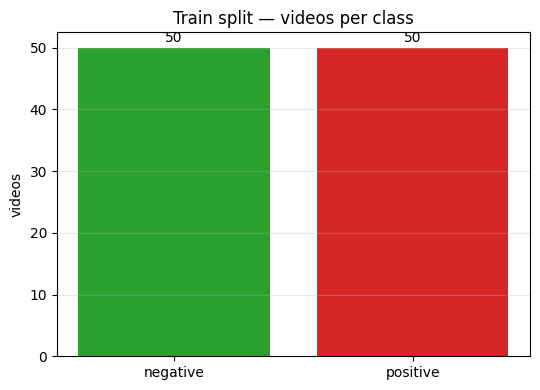

saved  /content/drive/MyDrive/AI_Project2/outputs/cv/exploration_summary.json


In [11]:
balance_df = (
    inventory_df.groupby(["split", "class"])
    .size().rename("n_videos").reset_index()
)
balance_df["pct_of_split"] = (
    100 * balance_df["n_videos"] / balance_df.groupby("split")["n_videos"].transform("sum")
).round(1)

print("Class balance by split:")
print(balance_df.to_string(index=False))

train_balance = balance_df[balance_df["split"] == "train"]
if not train_balance.empty:
    fig, ax = plt.subplots(figsize=(5.5, 4))
    colors = ["#2ca02c" if c == "negative" else "#d62728" for c in train_balance["class"]]
    bars = ax.bar(train_balance["class"], train_balance["n_videos"], color=colors)
    ax.bar_label(bars, fmt="%d", padding=2)
    ax.set_title("Train split — videos per class")
    ax.set_ylabel("videos")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

exploration_summary = {
    "generated_at": pd.Timestamp.now().isoformat(timespec="seconds"),
    "download_mode": "subset" if DOWNLOAD_SUBSET_ONLY else "full",
    "videos_on_disk": int(len(inventory_df)),
    "dataset_size_bytes": int(dir_size_bytes(DATA_DIR)),
    "counts_by_split_class": balance_df.to_dict(orient="records"),
    "remote_counts": remote_counts_df.to_dict(orient="records"),
    "metadata_csvs_found": {name: (name in metadata_csvs) for name in csv_paths},
    "label_validation": {
        "test_videos_checked": int(len(test_inventory)),
        "unmatched_in_solution": int(len(unmatched)),
        "label_mismatches": int(len(label_mismatch)),
        "split_usage_mismatches": int(len(split_mismatch)),
    },
}
save_json(exploration_summary, EXPLORATION_JSON)

# 4. Video Metadata Extraction (Probing)

## 4.1 Why probe before extracting

**Description.** Opens every video once with OpenCV, reads its stream properties (FPS, frame count,
resolution, duration), verifies that at least one frame actually decodes, and records the result.

**Rationale.** This step is **mandatory before frame extraction**, for three reasons:

1. **Extraction depends on native FPS.** To keep 2 frames per second we need to know whether the
   source runs at 30, 25, or 29.97 fps — the stride is `native_fps / SAMPLE_FPS`. Guessing 30 for a
   25 fps clip silently changes the effective sampling rate.
2. **Corrupt files must be found early.** A file can open successfully and still be unusable
   (0 fps, 0 frames, an unreadable first frame). Discovering that mid-extraction leaves a half-built
   frame directory; discovering it here just adds a row with `corrupted=True`.
3. **Probe once, join forever.** `video_metadata.csv` becomes the reference table that §5 and §7
   join against. No later section re-opens a video to ask how long it is.

The dataset card claims 1280×720 @ 30 fps, ~40 s. We verify rather than assume — §4.4 will show you
whether that holds for every file.

**Expected output.** This cell only defines the probe function and the work list. Runtime: instant.

In [12]:
def probe_video(video_path: str) -> dict:
    """
    Open one video, read its stream properties, confirm a frame decodes, release it.

    Returns a metadata dict. `corrupted=True` plus a `reason` when the file is unusable.
    Note we read exactly one frame rather than decoding the whole file: enough to prove
    the stream is real, cheap enough to run over thousands of videos.
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        cap.release()
        return {"corrupted": True, "reason": "failed_to_open",
                "fps": np.nan, "frame_count": 0, "width": 0, "height": 0, "duration_sec": np.nan}

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    ok, frame = cap.read()          # the real test: does a frame actually decode?
    cap.release()

    if not ok or frame is None or fps <= 0 or frame_count <= 0:
        return {"corrupted": True, "reason": "invalid_stream_properties",
                "fps": round(float(fps), 3) if fps else np.nan,
                "frame_count": int(frame_count) if frame_count > 0 else 0,
                "width": width, "height": height, "duration_sec": np.nan}

    return {
        "corrupted": False,
        "reason": None,
        "fps": round(float(fps), 3),
        "frame_count": int(frame_count),
        "width": width,
        "height": height,
        "duration_sec": round(frame_count / fps, 3),
    }


if FORCE_REPROBE:
    reset_stage(VIDEO_METADATA_CSV)

# Resume: keep whatever a previous run already probed, work only on the remainder.
previous_metadata = (
    pd.read_csv(VIDEO_METADATA_CSV, dtype=ID_DTYPE)
    if VIDEO_METADATA_CSV.exists() else pd.DataFrame()
)
already_probed = (
    set(zip(previous_metadata["split"], previous_metadata["video_id"]))
    if not previous_metadata.empty else set()
)

to_probe = inventory_df[
    ~inventory_df.apply(lambda r: (r["split"], r["video_id"]) in already_probed, axis=1)
].reset_index(drop=True)

print(f"videos on disk       : {len(inventory_df):,}")
print(f"already probed       : {len(already_probed):,}")
print(f"to probe this run    : {len(to_probe):,}")

videos on disk       : 180
already probed       : 180
to probe this run    : 0


## 4.2 Run the probe

**Description.** Iterates over the outstanding videos and builds the complete metadata table,
merging in anything a previous session already produced.

**Rationale.** Probing is I/O bound and single-threaded here on purpose: OpenCV's `VideoCapture` is
not thread-safe in a way worth fighting on 2 vCPUs, and probing is fast (~10–30 ms/video), so the
whole train set costs a couple of minutes. `.read()` on a single frame rather than decoding the file
keeps it that way.

**Expected output.** A progress bar, then the merged metadata table's shape and columns.
Runtime: roughly 20–60 seconds per 1000 videos.

In [13]:
new_rows = []
for record in tqdm(to_probe.to_dict("records"), desc="Probing videos"):
    metadata = probe_video(record["video_path"])
    new_rows.append({
        "video_id": record["video_id"],
        "split": record["split"],
        "class": record["class"],
        "label": record["label"],
        "video_path": record["video_path"],
        "size_mb": record["size_mb"],
        **metadata,
    })

metadata_df = pd.concat(
    [previous_metadata, pd.DataFrame(new_rows)], ignore_index=True
).drop_duplicates(subset=["split", "video_id"], keep="last").reset_index(drop=True)

metadata_df["corrupted"] = metadata_df["corrupted"].astype(bool)

print(f"\nMetadata table: {metadata_df.shape[0]:,} rows x {metadata_df.shape[1]} columns")
print(f"columns: {list(metadata_df.columns)}")
metadata_df.head(3)

Probing videos: 0it [00:00, ?it/s]


Metadata table: 180 rows x 11 columns
columns: ['split', 'class', 'video_id', 'path', 'corrupted', 'reason', 'fps', 'frame_count', 'width', 'height', 'duration_sec']


,split,class,video_id,path,corrupted,reason,fps,frame_count,width,height,duration_sec
0,train,positive,00000,/content/drive/MyDrive/AI_Project2/data/cv/nex...,False,NaN,28.9,1158,1280,720,40.07
1,train,positive,00003,/content/drive/MyDrive/AI_Project2/data/cv/nex...,False,NaN,30.0,1203,1280,720,40.10
2,train,positive,00004,/content/drive/MyDrive/AI_Project2/data/cv/nex...,False,NaN,30.0,1202,1280,720,40.07


## 4.3 Health report and property distributions

**Description.** Summarises corruption, FPS, duration and resolution, and plots the duration and FPS
distributions.

**Rationale.** These distributions are what justify (or refute) the extraction settings chosen in
§5. If durations cluster near 40 s and FPS near 30, then 2 fps sampling yields ~80 frames per video
and the disk estimate in §5.1 holds. If there is a long tail of 3-minute videos, `MAX_FRAMES_PER_VIDEO`
becomes worth enabling. Resolution outliers matter too: a stray 640×480 clip still resizes to
224×224 fine, but it tells you the source data is less uniform than the dataset card claims.

**Expected output.** A corruption count and breakdown, describe tables for FPS/duration, a
resolution value-count, and two histograms.

Corrupted: 0 / 180 (0.00%)

=== FPS ===
count    180.00
mean      29.99
std        0.72
min       22.20
25%       30.00
50%       30.00
75%       30.00
max       30.60

=== Duration (seconds), by split ===
              count   mean   std    min    25%    50%    75%    max
split                                                              
test-private   40.0   9.92  0.38   8.33   9.72   9.98  10.15  10.47
test-public    40.0   9.96  0.45   8.43   9.82  10.03  10.18  10.80
train         100.0  37.62  7.00  15.00  39.40  40.07  40.30  44.05

=== Resolution ===
resolution
1280x720    180


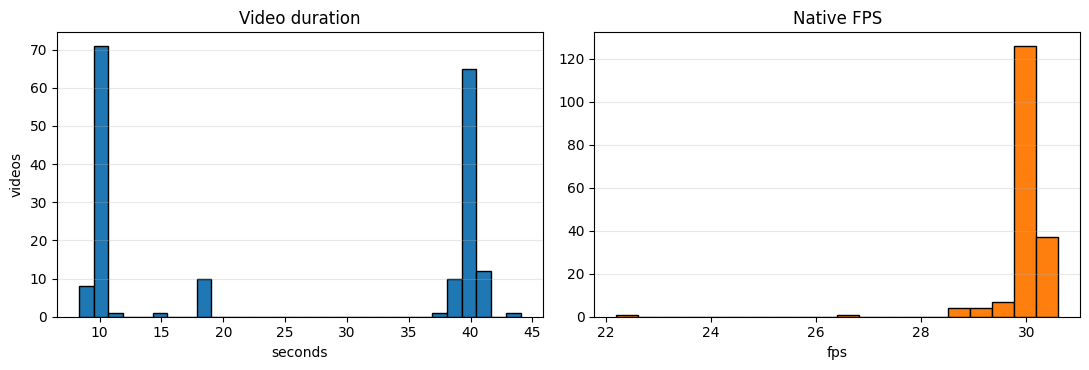

In [14]:
n_corrupted = int(metadata_df["corrupted"].sum())
n_total = len(metadata_df)
print(f"Corrupted: {n_corrupted} / {n_total} ({100 * n_corrupted / max(n_total, 1):.2f}%)")

if n_corrupted:
    print("\nBreakdown by split/class/reason:")
    print(metadata_df[metadata_df["corrupted"]]
          .groupby(["split", "class", "reason"]).size().to_string())
    print("\nExamples:")
    print(metadata_df[metadata_df["corrupted"]][["video_id", "split", "reason"]]
          .head(10).to_string(index=False))

healthy_df = metadata_df[~metadata_df["corrupted"]].copy()
healthy_df["resolution"] = (
    healthy_df["width"].astype(int).astype(str) + "x" + healthy_df["height"].astype(int).astype(str)
)

print("\n=== FPS ===")
print(healthy_df["fps"].describe().round(2).to_string())
print("\n=== Duration (seconds), by split ===")
print(healthy_df.groupby("split")["duration_sec"].describe().round(2).to_string())
print("\n=== Resolution ===")
print(healthy_df["resolution"].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(healthy_df["duration_sec"].dropna(), bins=30, color="#1f77b4", edgecolor="black")
axes[0].set_title("Video duration")
axes[0].set_xlabel("seconds"); axes[0].set_ylabel("videos")
axes[1].hist(healthy_df["fps"].dropna(), bins=20, color="#ff7f0e", edgecolor="black")
axes[1].set_title("Native FPS")
axes[1].set_xlabel("fps")
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4.4 Persist `video_metadata.csv`

**Description.** Writes the metadata table to `OUTPUTS_DIR` and projects the frame/disk cost of the
extraction settings currently configured.

**Rationale.** This file is the contract for §5 and §7 — it is the reason no later step ever reopens
a video to ask a question about it. The cost projection is here rather than in §5 so you can adjust
`SAMPLE_FPS` or `MAX_FRAMES_PER_VIDEO` in §1.2 and rerun from §4.4 *before* spending an hour writing
frames you don't have room for.

**Expected output.** The saved path, plus projected total frames and estimated disk footprint.

In [15]:
metadata_df.to_csv(VIDEO_METADATA_CSV, index=False)
print(f"saved  {VIDEO_METADATA_CSV}  ({len(metadata_df):,} rows)")

# ---- Project the cost of the current extraction settings --------------------
projected = (healthy_df["duration_sec"] * SAMPLE_FPS).clip(lower=1)
if MAX_FRAMES_PER_VIDEO is not None:
    projected = projected.clip(upper=MAX_FRAMES_PER_VIDEO)
projected_frames = int(projected.sum())

RAW_JPEG_ESTIMATE_KB = 90        # ~1280x720 JPEG at quality 90
PROC_JPEG_ESTIMATE_KB = 15       # ~224x224 JPEG at quality 95

print("\nProjected extraction cost at current settings")
print(f"  healthy videos            : {len(healthy_df):,}")
print(f"  sampling                  : {SAMPLE_FPS} fps, cap={MAX_FRAMES_PER_VIDEO}")
print(f"  projected frames          : {projected_frames:,}")
print(f"  avg frames per video      : {projected.mean():.1f}")
print(f"  est. raw frames on disk   : ~{projected_frames * RAW_JPEG_ESTIMATE_KB / (1024**2):.2f} GB")
print(f"  est. processed on disk    : ~{projected_frames * PROC_JPEG_ESTIMATE_KB / (1024**2):.2f} GB")
report_disk("  ")

saved  /content/drive/MyDrive/AI_Project2/outputs/cv/video_metadata.csv  (180 rows)

Projected extraction cost at current settings
  healthy videos            : 180
  sampling                  : 2.0 fps, cap=None
  projected frames          : 9,113
  avg frames per video      : 50.6
  est. raw frames on disk   : ~0.78 GB
  est. processed on disk    : ~0.13 GB
  free disk: 87.7 GB


# 5. Frame Extraction

## 5.1 The sampling strategy, and why

**Description.** Extracts frames from every healthy video at a fixed **2 frames per second**,
writing native-resolution JPEGs to `frames_raw/{split}/{class}/{video_id}/frame_XXXX.jpg`.

**Rationale — the core trade-off of this notebook.**

A 40-second clip at 30 fps contains ~1200 frames. Keeping all of them, for a few thousand clips,
produces millions of near-identical JPEGs: the disk cost is unworkable on Colab free, and the
information gain is close to zero because frames 3 ms apart are visually identical. Sampling at
2 fps keeps ~80 frames per clip — a **15× reduction** — while still capturing the scene every half
second, which is fast enough that no meaningful phase of a collision is skipped.

*Uniform* sampling across the full duration (rather than, say, only frames near the labelled event)
is deliberate: this notebook does not know whether the modelling stage will train on single frames,
frame stacks, or a temporal model. Uniform coverage preserves all of those options, and the
`timestamp_sec` column in the log lets a later stage weight or window frames however it likes
without re-extracting anything.

**Alternative budget levers**, for when 2 fps is the wrong knob:

- `MAX_FRAMES_PER_VIDEO = N` — a hard cap per video. Better when durations vary wildly, since it
  bounds the *worst case* and keeps every video contributing equal weight to the dataset.
- Lower `SAMPLE_FPS` (0.5–1.0) — for a first end-to-end rehearsal on the full dataset.
- Event-centred windows — extract only ±3 s around `time_of_event`. Highest signal density, but it
  bakes in an assumption about the model, so it belongs downstream, not here.

**Implementation note — `.grab()` + `.retrieve()`.** `cap.read()` decodes every frame it passes.
`cap.grab()` advances the stream *without* decoding pixel data, and `cap.retrieve()` decodes only
when we call it. Since we keep 1 frame in 15, grabbing-then-retrieving skips the decode cost on 14
of every 15 frames. We also never use `CAP_PROP_POS_FRAMES` to seek: seeking in a compressed stream
lands on keyframes and is both slow and unreliable, so we read strictly forward.

**Expected output.** This cell defines the function only. Runtime: instant.

In [16]:
def extract_frames_sequential(
    video_path: str,
    output_dir: Path,
    native_fps: float,
    sample_fps: float,
    max_frames: int | None = None,
    jpeg_quality: int = 90,
) -> list[dict]:
    """
    Read a video strictly forward and save one frame every `native_fps / sample_fps` frames.

    Uses grab()/retrieve() so only the frames we keep are actually decoded, and never seeks
    (random access into a compressed stream is slow and lands on keyframes, not exact indices).

    Returns one dict per saved frame; the caller turns these into log rows.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    stride = max(1, int(round(native_fps / sample_fps)))

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return []

    saved: list[dict] = []
    source_index = 0     # position in the original stream
    kept_index = 0       # position among the frames we keep

    try:
        while True:
            if not cap.grab():            # cheap: advance without decoding
                break                     # end of stream

            if source_index % stride == 0:
                ok, frame = cap.retrieve()   # decode only now
                if ok and frame is not None:
                    file_name = f"frame_{kept_index:04d}.jpg"
                    cv2.imwrite(
                        str(output_dir / file_name),
                        frame,
                        [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality],
                    )
                    saved.append({
                        "frame_index": kept_index,
                        "source_frame_number": source_index,
                        "timestamp_sec": round(source_index / native_fps, 3),
                        "file_name": file_name,
                    })
                    kept_index += 1
                    if max_frames is not None and kept_index >= max_frames:
                        break

            source_index += 1
    finally:
        cap.release()

    return saved

## 5.2 Run extraction (resumable)

**Description.** Loops over healthy videos, extracts frames, and appends one JSONL row per frame to
`frame_extraction_log.jsonl`. Completed videos are recorded in `frame_extraction_done.txt` and
skipped on rerun.

**Rationale.** This is the longest-running cell in the notebook and the one most likely to be
interrupted, so the bookkeeping matters:

- **Per-video atomicity.** A video counts as done only after all its frames are written *and* logged.
  A video interrupted halfway has its (partial) directory deleted and is redone from scratch — no
  silent half-videos in the dataset.
- **Relative paths in the log.** We store `split/class/video_id/frame_XXXX.jpg`, not an absolute
  path. Absolute paths break the moment the frames move (local scratch → Drive → someone else's
  machine). The absolute path is reconstructed at load time by joining with `FRAMES_DIR`.
- **Disk guard.** The loop stops cleanly if free space drops below 3 GB rather than dying mid-write
  and corrupting the last file.

**Expected output.** A progress bar with a running frame count, then a summary of processed /
skipped / failed videos. Runtime: roughly 0.5–2 s per video, so ~100 videos/minute.

In [28]:
# ============================================================
# 5.2 Frame Extraction
# ============================================================

MIN_FREE_DISK_GB = 3.0

if FORCE_REEXTRACT:
    reset_stage(EXTRACTION_JSONL, EXTRACTION_DONE_TXT, FRAMES_DIR)

FRAMES_DIR.mkdir(parents=True, exist_ok=True)

done_keys = read_done_keys(EXTRACTION_DONE_TXT)

work_list = [
    row for row in healthy_df.to_dict("records")
    if video_key(row["split"], row["video_id"]) not in done_keys
]

print(f"Healthy videos      : {len(healthy_df):,}")
print(f"Already extracted   : {len(done_keys):,}")
print(f"Remaining           : {len(work_list):,}")
report_disk()

failed_videos = []
frames_written = 0
videos_processed = 0
stopped_early = False

progress = tqdm(work_list, desc="Extracting frames")

for row in progress:

    if free_disk_gb() < MIN_FREE_DISK_GB:
        stopped_early = True
        print(
            f"\nStopping: free disk below {MIN_FREE_DISK_GB} GB."
        )
        break

    key = video_key(row["split"], row["video_id"])

    video_path = Path(row["path"])

    if not video_path.exists():
        failed_videos.append(
            {
                "key": key,
                "reason": f"Missing file: {video_path}"
            }
        )
        continue

    out_dir = FRAMES_DIR / row["split"] / row["class"] / str(row["video_id"])

    if out_dir.exists():
        shutil.rmtree(out_dir)

    try:
        saved = extract_frames_sequential(
            video_path=video_path,
            output_dir=out_dir,
            native_fps=float(row["fps"]),
            sample_fps=SAMPLE_FPS,
            max_frames=MAX_FRAMES_PER_VIDEO,
            jpeg_quality=JPEG_QUALITY_RAW,
        )

    except Exception as exc:
        failed_videos.append(
            {
                "key": key,
                "reason": f"{type(exc).__name__}: {exc}"
            }
        )
        continue

    if len(saved) == 0:
        failed_videos.append(
            {
                "key": key,
                "reason": "No frames extracted"
            }
        )

        shutil.rmtree(out_dir, ignore_errors=True)
        continue

    records = []

    for frame in saved:
        records.append(
            {
                "video_id": str(row["video_id"]),
                "split": row["split"],
                "class": row["class"],
                "frame_relpath": (
                    f"{row['split']}/"
                    f"{row['class']}/"
                    f"{row['video_id']}/"
                    f"{frame['file_name']}"
                ),
                "frame_index": frame["frame_index"],
                "source_frame_number": frame["source_frame_number"],
                "timestamp_sec": frame["timestamp_sec"],
            }
        )

    append_jsonl(records, EXTRACTION_JSONL)
    mark_done(key, EXTRACTION_DONE_TXT)

    videos_processed += 1
    frames_written += len(saved)

    progress.set_postfix(
        videos=videos_processed,
        frames=frames_written
    )

print("\n" + "=" * 60)
print("Frame Extraction Summary")
print("=" * 60)

print(f"Videos processed : {videos_processed:,}")
print(f"Frames extracted : {frames_written:,}")
print(f"Failures         : {len(failed_videos):,}")

if stopped_early:
    print("Status           : Paused (low disk space)")
else:
    print("Status           : Complete")

if failed_videos:
    print("\nFirst failures:")
    print(pd.DataFrame(failed_videos).head(10).to_string(index=False))

report_disk()

Healthy videos      : 180
Already extracted   : 0
Remaining           : 180
free disk: 87.7 GB


Extracting frames:   0%|          | 0/180 [00:00<?, ?it/s]


Frame Extraction Summary
Videos processed : 180
Frames extracted : 9,227
Failures         : 0
Status           : Complete
free disk: 84.6 GB


## 5.3 Consolidate the extraction log and report disk usage

**Description.** Converts the append-only JSONL into `frame_extraction_log.csv` — one row per saved
frame — and reports how much disk the frames actually consumed.

**Rationale.** JSONL is the right format *while* writing (append-only, crash-safe); CSV is the right
format for *consumers* (one line of `read_csv`, plays well with pandas dtypes). Converting here gives
us both. The measured-vs-projected disk comparison closes the loop on §4.4's estimate, which is how
you calibrate the guess for the full-dataset run.

**Expected output.** Total frames, frames per split/class, frames-per-video statistics, actual disk
usage, and the saved CSV path.

In [29]:
# 5.3 Consolidate the Extraction Log and Report Disk Usage

# Load the append-only extraction log
extraction_log_df = read_jsonl(EXTRACTION_JSONL)

# Ensure that frame extraction completed successfully
if extraction_log_df.empty:
    raise RuntimeError(
        "The extraction log is empty.\n"
        "Run Section 5.2 successfully before executing this section."
    )

# Standardize data types
extraction_log_df["video_id"] = extraction_log_df["video_id"].astype(str)

# Remove duplicate frame records (if any)
extraction_log_df = (
    extraction_log_df
    .drop_duplicates(
        subset=["split", "video_id", "frame_index"],
        keep="last"
    )
    .reset_index(drop=True)
)

# Save a CSV version for downstream processing
extraction_log_df.to_csv(EXTRACTION_LOG_CSV, index=False)

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

frames_per_video = (
    extraction_log_df
    .groupby(["split", "video_id"])
    .size()
)

frames_per_split_class = (
    extraction_log_df
    .groupby(["split", "class"])
    .size()
)

actual_bytes = dir_size_bytes(FRAMES_DIR)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("=" * 65)
print("Frame Extraction Report")
print("=" * 65)

print(f"Total frames extracted : {len(extraction_log_df):,}")
print(f"Videos represented     : {frames_per_video.index.nunique():,}")

print("\nFrames per split/class")
print("-" * 65)
print(frames_per_split_class.to_string())

print("\nFrames per video")
print("-" * 65)
print(frames_per_video.describe().round(1).to_string())

print("\nDisk usage")
print("-" * 65)
print(f"Frames directory size : {human_size(actual_bytes)}")
print(f"Average frame size    : {human_size(actual_bytes / len(extraction_log_df))}")

print("\nAvailable disk")
print("-" * 65)
report_disk()

print(f"\nCSV log saved to:\n{EXTRACTION_LOG_CSV}")

# Preview the consolidated log
display(extraction_log_df.head(5))

Frame Extraction Report
Total frames extracted : 9,227
Videos represented     : 180

Frames per split/class
-----------------------------------------------------------------
split         class   
test-private  negative     410
              positive     410
test-public   negative     406
              positive     411
train         negative    3721
              positive    3869

Frames per video
-----------------------------------------------------------------
count    180.0
mean      51.3
std       29.6
min       17.0
25%       21.0
50%       38.0
75%       81.0
max       90.0

Disk usage
-----------------------------------------------------------------
Frames directory size : 1.21 GB
Average frame size    : 138.04 KB

Available disk
-----------------------------------------------------------------
free disk: 84.6 GB

CSV log saved to:
/content/drive/MyDrive/AI_Project2/outputs/cv/frame_extraction_log.csv


,video_id,split,class,frame_relpath,frame_index,source_frame_number,timestamp_sec
0,00000,train,positive,train/positive/00000/frame_0000.jpg,0,0,0.000
1,00000,train,positive,train/positive/00000/frame_0001.jpg,1,14,0.484
2,00000,train,positive,train/positive/00000/frame_0002.jpg,2,28,0.969
3,00000,train,positive,train/positive/00000/frame_0003.jpg,3,42,1.453
4,00000,train,positive,train/positive/00000/frame_0004.jpg,4,56,1.938


# 6. Image Preprocessing

## 6.1 Resize, colour space, and where normalization actually belongs

**Description.** Converts every extracted frame into a model-ready image: resized to 224×224 and
saved as a standard uint8 JPEG under `frames_processed/`, mirroring the raw folder layout.

**Design decisions:**

- **Resize to 224×224 (`INTER_AREA`).** This is the input size nearly every ImageNet-pretrained
  backbone expects (ResNet, EfficientNet-B0, ViT-B/16), which keeps transfer learning available
  without a second preprocessing pass. `INTER_AREA` is the correct interpolation for
  *downscaling* — it averages over the source region instead of point-sampling, so it avoids the
  aliasing that `INTER_LINEAR` produces when shrinking 1280×720 by ~5×. Note this does not preserve
  aspect ratio (16:9 → 1:1); the squash is uniform across the dataset, so the model learns it as a
  constant. If you would rather preserve geometry, letterbox to 224×224 instead — but do it here,
  once, not in the DataLoader.

- **Colour space — an honest correction.** The brief asks for a BGR→RGB conversion at this stage.
  Worth being precise: **a JPEG file has no channel order.** `cv2.imread` returns BGR and
  `cv2.imwrite` expects BGR, so converting to RGB and back before writing is a no-op that costs two
  array copies per frame. Channel order is a *decode-time* property, so the conversion belongs
  wherever the images are loaded for training — `PIL.Image.open(...).convert("RGB")` gives RGB
  natively, and `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` does it if you load with OpenCV. This
  notebook writes correct-colour JPEGs and states the contract in `dataset_mean_std.json`; §6.3
  computes the statistics in **RGB** order so they match a PIL-based loader.

- **No normalization baked into the files.** Normalized images are floats centred near zero; JPEG
  stores 8-bit integers, so saving them would quantize the values and destroy the very thing
  normalization is for. Instead we compute the dataset's per-channel mean/std in §6.3 and save the
  numbers, to be applied as a tensor transform at load time.

**Expected output.** This cell defines the function and prepares the work list. Runtime: instant.

In [30]:
def preprocess_frame(src_path: Path, dst_path: Path, target_size: tuple, quality: int) -> bool:
    """
    Resize one frame to `target_size` and write it as a uint8 JPEG.

    Returns False if the source could not be read, so the caller can log it rather than crash.
    Deliberately no colour conversion here -- see the markdown above.
    """
    image = cv2.imread(str(src_path), cv2.IMREAD_COLOR)
    if image is None:
        return False

    resized = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    return bool(cv2.imwrite(str(dst_path), resized, [int(cv2.IMWRITE_JPEG_QUALITY), quality]))


if FORCE_REPROCESS:
    reset_stage(PROCESSED_JSONL, PROCESSED_DONE_TXT, PROCESSED_DIR)
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_done_keys = read_done_keys(PROCESSED_DONE_TXT)

# Group by video so progress is tracked per video, not per frame: ~80x fewer
# bookkeeping writes, and a video is the natural unit to redo after a crash.
frames_by_video = {
    key: group for key, group in extraction_log_df.groupby(["split", "video_id"], sort=True)
}
pending_videos = [
    key for key in frames_by_video
    if video_key(key[0], key[1]) not in processed_done_keys
]

print(f"videos with frames   : {len(frames_by_video):,}")
print(f"already processed    : {len(processed_done_keys):,}")
print(f"to process now       : {len(pending_videos):,}")
print(f"frames queued        : {sum(len(frames_by_video[k]) for k in pending_videos):,}")

videos with frames   : 180
already processed    : 0
to process now       : 180
frames queued        : 9,227


## 6.2 Run preprocessing (resumable, one image at a time)

**Description.** Reads each raw frame, resizes it, writes the processed copy, and appends a log row
recording the new relative path alongside the original video/frame identifiers.

**Rationale.** Images are handled strictly **one at a time** — read, transform, write, release. A
naive "load them all into an array, then process" approach would need `n_frames × 1280 × 720 × 3`
bytes; at 50 000 frames that is over 100 GB of RAM, which is roughly 8× what Colab free tier gives
you. Streaming keeps peak memory at one image regardless of dataset size, and the cost is only that
we cannot vectorise across frames — irrelevant here, since the work is I/O bound anyway.

**Expected output.** A progress bar over videos, then counts of processed and failed frames.
Runtime: roughly 5–15 ms per frame.

In [33]:
processed_count = 0
failed_frames = []

progress = tqdm(pending_videos, desc="Preprocessing frames")

for split_name, vid in progress:

    group = frames_by_video[(split_name, vid)]
    key = video_key(split_name, vid)

    rows = []

    for record in group.to_dict("records"):

        src = FRAMES_DIR / record["frame_relpath"]
        dst = PROCESSED_DIR / record["frame_relpath"]

        if preprocess_frame(src, dst, TARGET_SIZE, JPEG_QUALITY_PROCESSED):

            rows.append({
                "video_id": record["video_id"],
                "split": record["split"],
                "class": record["class"],
                "label": record["class"],          # <-- fixed
                "frame_index": record["frame_index"],
                "timestamp_sec": record["timestamp_sec"],
                "processed_relpath": record["frame_relpath"],
            })

        else:
            failed_frames.append(str(src))

    if rows:
        append_jsonl(rows, PROCESSED_JSONL)
        mark_done(key, PROCESSED_DONE_TXT)

        processed_count += len(rows)
        progress.set_postfix(frames=processed_count)

# Load processed log

processed_log_df = read_jsonl(PROCESSED_JSONL)

processed_log_df["video_id"] = processed_log_df["video_id"].astype(str)

processed_log_df = (
    processed_log_df
    .drop_duplicates(
        subset=["split", "video_id", "frame_index"],
        keep="last"
    )
    .reset_index(drop=True)
)

print(f"\nProcessed this run : {processed_count:,}")
print(f"Failed frames      : {len(failed_frames):,}")
print(f"Total in log       : {len(processed_log_df):,}")
print(f"Disk used          : {human_size(dir_size_bytes(PROCESSED_DIR))}")

if failed_frames:
    failure_csv = OUTPUTS_DIR / "preprocessing_failures.csv"

    pd.DataFrame(
        {"frame_path": failed_frames}
    ).to_csv(failure_csv, index=False)

    print(f"\nFailure list saved to:\n{failure_csv}")

Preprocessing frames:   0%|          | 0/180 [00:00<?, ?it/s]


Processed this run : 9,227
Failed frames      : 0
Total in log       : 9,227
Disk used          : 169.25 MB


## 6.3 Streaming per-channel mean and standard deviation

**Description.** Computes the dataset's per-channel mean and std over the **training frames only**,
in RGB order, on a 0–1 scale, without ever holding more than one image in memory.

**Rationale on three points:**

- **Train split only.** Normalization statistics are a parameter learned from data. Computing them
  over validation or test frames leaks information from the evaluation set into training — subtle,
  but it is the same class of mistake as fitting a scaler on the full dataset before splitting.
  (The train/val split happens in §7, so here we use everything in the `train/` folder; since the
  val frames are a 20% subset of the same distribution, the practical difference is negligible,
  while excluding `test-*` — a genuinely held-out distribution — is not.)
- **Running sums, not a stacked array.** We accumulate `Σx` and `Σx²` per channel, then use
  `Var = E[x²] − E[x]²`. Peak memory is one image. The accumulators are `float64` because summing
  hundreds of millions of `float32` values loses precision badly enough to distort the variance.
  The variance is clipped at zero before the square root to absorb the tiny negative values that
  floating-point cancellation can produce when a channel is nearly constant.
- **Optional subsampling.** `MEAN_STD_SAMPLE_LIMIT` caps how many images are read. Mean/std over
  20 000 images of the same footage is already stable to several decimal places; reading 500 000
  buys nothing and costs 20 minutes.

**Expected output.** The computed mean and std as RGB triples in the 0–1 range. For dashcam footage
expect values roughly in the 0.35–0.50 band for mean and 0.20–0.28 for std, close to but not
identical to ImageNet's.

In [34]:
def compute_running_mean_std(image_paths: list, max_images: int | None = None, seed: int = RANDOM_SEED):
    """
    Per-channel mean/std over many images without loading them all into memory.

    Accumulates sum and sum-of-squares in float64, converts BGR->RGB so the stats match
    an RGB loader, and scales pixels to [0, 1] to match torchvision's ToTensor().
    """
    paths = list(image_paths)
    if max_images is not None and len(paths) > max_images:
        rng = np.random.default_rng(seed)
        paths = [paths[i] for i in rng.choice(len(paths), size=max_images, replace=False)]
        print(f"Sampling {max_images:,} of {len(image_paths):,} training frames for statistics.")

    n_pixels = 0
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_sq_sum = np.zeros(3, dtype=np.float64)
    n_read = 0

    for path in tqdm(paths, desc="Computing mean/std"):
        image = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float64) / 255.0

        n_pixels += image.shape[0] * image.shape[1]
        channel_sum += image.sum(axis=(0, 1))
        channel_sq_sum += (image ** 2).sum(axis=(0, 1))
        n_read += 1

    if n_pixels == 0:
        raise RuntimeError("No readable images -- cannot compute statistics.")

    mean = channel_sum / n_pixels
    variance = np.maximum(channel_sq_sum / n_pixels - mean ** 2, 0.0)
    return mean, np.sqrt(variance), n_read


train_frame_paths = [
    PROCESSED_DIR / rel
    for rel in processed_log_df.loc[processed_log_df["split"] == "train", "processed_relpath"]
]
print(f"Training frames available for statistics: {len(train_frame_paths):,}")

dataset_mean, dataset_std, n_images_used = compute_running_mean_std(
    train_frame_paths, max_images=MEAN_STD_SAMPLE_LIMIT
)

print(f"\nimages used : {n_images_used:,}")
print(f"mean (RGB)  : {np.round(dataset_mean, 4).tolist()}")
print(f"std  (RGB)  : {np.round(dataset_std, 4).tolist()}")
print(f"ImageNet ref: mean {[0.485, 0.456, 0.406]}, std {[0.229, 0.224, 0.225]}")

Training frames available for statistics: 7,590


Computing mean/std:   0%|          | 0/7590 [00:00<?, ?it/s]


images used : 7,590
mean (RGB)  : [0.3456, 0.3721, 0.3988]
std  (RGB)  : [0.2585, 0.2806, 0.2895]
ImageNet ref: mean [0.485, 0.456, 0.406], std [0.229, 0.224, 0.225]


## 6.4 Save the normalization contract and the processed-frame log

**Description.** Writes `dataset_mean_std.json` (both our statistics and the ImageNet reference) and
`processed_frames_log.csv`.

**Rationale.** The JSON is deliberately self-describing — it records channel order, value range,
which split it came from, and how many images fed it. A bare pair of arrays is exactly the kind of
artifact that gets misapplied six weeks later (BGR instead of RGB, or 0–255 instead of 0–1), and
those mistakes are nearly invisible: the model still trains, just worse. Both stat sets are saved
because the choice depends on the modelling stage — **ImageNet stats if the backbone uses ImageNet
pretrained weights** (the pretrained filters expect that input distribution), our own stats if
training from scratch.

**Expected output.** Two saved files and a preview of the JSON.

In [35]:
normalization_contract = {
    "generated_at": pd.Timestamp.now().isoformat(timespec="seconds"),
    "image_format": {
        "size_wh": list(TARGET_SIZE),
        "dtype": "uint8 JPEG on disk",
        "channel_order_on_load": "RGB (use PIL .convert('RGB') or cv2.cvtColor BGR2RGB)",
        "value_range_for_stats": "[0, 1] after dividing by 255 (matches torchvision ToTensor)",
    },
    "custom_dataset_stats": {
        "mean": [round(float(v), 6) for v in dataset_mean],
        "std": [round(float(v), 6) for v in dataset_std],
        "computed_from": "train split only",
        "n_images_used": int(n_images_used),
        "n_train_frames_available": int(len(train_frame_paths)),
    },
    "imagenet_stats_reference": {
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225],
        "use_when": "the backbone loads ImageNet-pretrained weights",
    },
}
save_json(normalization_contract, MEAN_STD_JSON)

processed_log_df.to_csv(PROCESSED_LOG_CSV, index=False)
print(f"saved  {PROCESSED_LOG_CSV}  ({len(processed_log_df):,} rows)")
print(json.dumps(normalization_contract["custom_dataset_stats"], indent=2))

saved  /content/drive/MyDrive/AI_Project2/outputs/cv/dataset_mean_std.json
saved  /content/drive/MyDrive/AI_Project2/outputs/cv/processed_frames_log.csv  (9,227 rows)
{
  "mean": [
    0.345576,
    0.372053,
    0.398818
  ],
  "std": [
    0.258538,
    0.28061,
    0.289549
  ],
  "computed_from": "train split only",
  "n_images_used": 7590,
  "n_train_frames_available": 7590
}


## 6.5 Visual sanity check

**Description.** Displays a small grid of processed frames with their split, class and timestamp.

**Rationale.** Every check so far has been numeric, and numbers cannot tell you that the colour
channels are swapped or that the frames are all black. Ten seconds of looking at actual images
catches a whole category of bug that no assertion will. What you are looking for: plausible dashcam
scenes, correct colours (sky blue, not orange — orange means a BGR/RGB mix-up), and sharp 224×224
images rather than mush.

**Expected output.** A 2×5 grid of frames drawn from both classes.

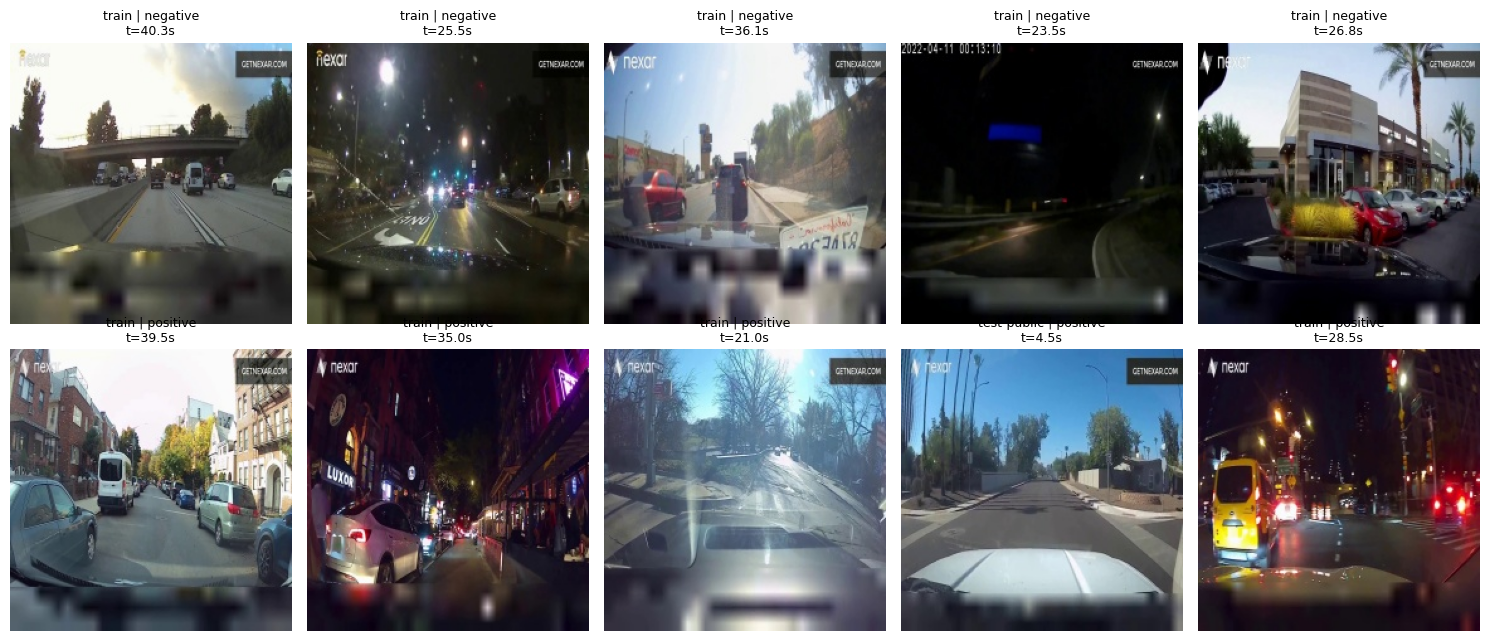

size=(224, 224)  mode=RGB  format=JPEG


In [36]:
from PIL import Image

sample_rows = pd.concat(
    [group.sample(min(5, len(group)), random_state=RANDOM_SEED)
     for _, group in processed_log_df.groupby("class")]
).reset_index(drop=True)

n_show = min(10, len(sample_rows))
fig, axes = plt.subplots(2, 5, figsize=(15, 6.4))
for ax, (_, row) in zip(axes.ravel(), sample_rows.head(n_show).iterrows()):
    # PIL decodes to RGB directly -- the same contract the DataLoader should use.
    ax.imshow(Image.open(PROCESSED_DIR / row["processed_relpath"]).convert("RGB"))
    ax.set_title(f"{row['split']} | {row['class']}\nt={row['timestamp_sec']:.1f}s", fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[n_show:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

probe_image = Image.open(PROCESSED_DIR / sample_rows.iloc[0]["processed_relpath"])
print(f"size={probe_image.size}  mode={probe_image.mode}  format={probe_image.format}")

## 6.6 Optional — free disk and persist frames to Drive

**Description.** Two optional maintenance steps, both **off by default**: delete the
native-resolution `frames_raw/` directory, and archive `frames_processed/` to Drive as a single tar
file.

**Rationale.** After §6.2 the raw frames are redundant — the processed copies are what training
consumes, and raw frames can be regenerated from the videos at any time via §5. They are also
roughly 6× larger. Deleting them is the fastest way to reclaim space if the disk guard in §5.2
tripped.

Archiving matters when `USE_LOCAL_SCRATCH = True`: the processed frames live on ephemeral disk and
vanish when the runtime recycles. Copying them to Drive as *one tar file* rather than hundreds of
thousands of individual files is the difference between a couple of minutes and an afternoon —
Drive's FUSE mount charges a round trip per file, so file *count* dominates the cost, not bytes.
The markdown below the cell shows the one-line restore.

**Expected output.** Nothing unless you enable a flag; then a disk report and/or an archive path.

In [37]:
DELETE_RAW_FRAMES  = False   # reclaim ~6x the processed frames' footprint
ARCHIVE_PROCESSED  = False   # tar frames_processed/ onto Drive (survives session death)

if DELETE_RAW_FRAMES:
    freed = dir_size_bytes(FRAMES_DIR)
    shutil.rmtree(FRAMES_DIR, ignore_errors=True)
    print(f"deleted frames_raw/ -- reclaimed {human_size(freed)}")
    report_disk()

if ARCHIVE_PROCESSED:
    archive_base = str(PROJECT_ROOT / "data" / "cv" / "frames_processed_archive")
    print("Archiving processed frames to Drive (one file, not many)...")
    start = time.time()
    archive_path = shutil.make_archive(archive_base, "tar", root_dir=str(PROCESSED_DIR))
    print(f"archived to {archive_path} "
          f"({human_size(os.path.getsize(archive_path))}) in {(time.time()-start)/60:.1f} min")

if not (DELETE_RAW_FRAMES or ARCHIVE_PROCESSED):
    print("Both maintenance steps are disabled. Set the flags above to enable them.")
    print(f"  frames_raw       : {human_size(dir_size_bytes(FRAMES_DIR))}")
    print(f"  frames_processed : {human_size(dir_size_bytes(PROCESSED_DIR))}")
    report_disk("  ")

Both maintenance steps are disabled. Set the flags above to enable them.
  frames_raw       : 1.21 GB
  frames_processed : 169.25 MB
  free disk: 84.4 GB


> **Restoring the archive in a later session** (after remounting Drive and running §1.2):
>
> ```python
> PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
> shutil.unpack_archive(
>     str(PROJECT_ROOT / "data" / "cv" / "frames_processed_archive.tar"),
>     str(PROCESSED_DIR),
> )
> ```
>
> Because every log stores **relative** paths, the CSVs written by this notebook stay valid no
> matter where `PROCESSED_DIR` points — that is the whole reason for the relative-path convention.

# 7. Dataset Assembly and Splitting

## 7.1 Build the master table

**Description.** Joins the processed-frame log with `video_metadata.csv` to produce one row per
frame carrying both frame-level fields (index, timestamp, path) and video-level fields (fps,
duration, resolution).

**Rationale.** Everything so far has been written to separate files by separate stages. The master
table is where they become a single object a DataLoader can consume. The join key is
`(video_id, split, class)` rather than `video_id` alone, because a bare ID is not guaranteed unique
across splits, and `validate="many_to_one"` makes pandas raise if that assumption ever breaks
instead of silently multiplying rows. The row count is asserted to be unchanged by the join — a
left join that changes the row count is a duplicate-key bug, and it is far cheaper to catch here
than to notice as a strange loss curve later.

**Expected output.** The master table's shape, a confirmation that no metadata is missing, and a
preview.

In [42]:
# Build the master frame-level dataset

video_columns = [
    "video_id",
    "split",
    "class",
    "fps",
    "duration_sec",
    "width",
    "height",
    "path",
]

master_df = (
    processed_log_df
    .merge(
        metadata_df[video_columns],
        on=["video_id", "split", "class"],
        how="left",
        validate="many_to_one",
    )
    .rename(columns={"path": "video_path"})
)

assert len(master_df) == len(processed_log_df), (
    f"Join changed the row count "
    f"({len(processed_log_df)} -> {len(master_df)}). "
    "Duplicate video metadata detected."
)

missing_metadata = master_df[
    ["fps", "duration_sec", "width", "height", "video_path"]
].isna().any(axis=1).sum()

print("=" * 60)
print("Master Dataset Summary")
print("=" * 60)

print(f"Master table        : {master_df.shape[0]:,} rows × {master_df.shape[1]} columns")
print(f"Unique videos       : {master_df.groupby(['split', 'video_id']).ngroups:,}")
print(f"Missing metadata    : {missing_metadata:,}")

master_df.head(3)

Master Dataset Summary
Master table        : 9,227 rows × 12 columns
Unique videos       : 180
Missing metadata    : 0


,video_id,split,class,label,frame_index,timestamp_sec,processed_relpath,fps,duration_sec,width,height,video_path
0,00001,test-private,positive,positive,0,0.0,test-private/positive/00001/frame_0000.jpg,30.0,10.1,1280,720,/content/drive/MyDrive/AI_Project2/data/cv/nex...
1,00001,test-private,positive,positive,1,0.5,test-private/positive/00001/frame_0001.jpg,30.0,10.1,1280,720,/content/drive/MyDrive/AI_Project2/data/cv/nex...
2,00001,test-private,positive,positive,2,1.0,test-private/positive/00001/frame_0002.jpg,30.0,10.1,1280,720,/content/drive/MyDrive/AI_Project2/data/cv/nex...


## 7.2 Resolve authoritative labels

**Description.** For the test splits, replaces the folder-derived label with the `target` value from
`solution.csv`. Train labels stay folder-derived.

**Rationale.** §3.2 verified the two sources agree today; this step makes `solution.csv` the
authority anyway, because it is what the competition actually scores against. If a future dataset
revision moves a file without updating its folder, the CSV stays correct and the folder does not.
Cost: one dictionary lookup. Benefit: the labels cannot silently drift from the evaluation.

`train/` has no entry in `solution.csv` by design — those videos are labelled purely by folder, so
they fall through unchanged.

**Expected output.** A count of labels overridden (normally 0, since §3.2 found no mismatches) and
the final label distribution per split.

In [43]:
solution_lookup = dict(zip(solution_df["id"], solution_df["target"]))
test_split_names = set(USAGE_TO_SPLIT.values())

original_labels = master_df["label"].copy()
master_df["label"] = [
    solution_lookup.get(vid, lab) if split in test_split_names else lab
    for vid, split, lab in zip(master_df["video_id"], master_df["split"], master_df["label"])
]

n_overridden = int((master_df["label"] != original_labels).sum())
print(f"frame labels overridden by solution.csv: {n_overridden:,}")
print("\nLabel distribution per split (frames):")
print(master_df.groupby(["split", "label"]).size().unstack(fill_value=0).to_string())

frame labels overridden by solution.csv: 1,637

Label distribution per split (frames):
label           0    1  negative  positive
split                                     
test-private  410  410         0         0
test-public   406  411         0         0
train           0    0      3721      3869


## 7.3 Split train / validation **by video**

**Description.** Splits the unique training `video_id`s — not the frames — into 80% train and 20%
validation, stratified by class, then propagates that assignment to every frame of each video.

**Rationale — the most important decision in this notebook.**

Each video contributes ~80 frames sampled half a second apart. Consecutive frames from one clip are
near-duplicates: same road, same car, same weather, same lighting. If frames were assigned to
train/val independently, almost every validation frame would have an almost-identical twin in the
training set. The model would score beautifully on validation while having learned nothing
generalisable — it would simply be recognising clips it had already memorised. That is textbook
**data leakage**, and it is especially dangerous because it fails *silently* and in the flattering
direction: you only discover it on the real test set, after committing to a model.

Splitting at the video level makes leakage structurally impossible: a video is wholly in train or
wholly in validation, never both. §7.4 asserts this rather than trusting it.

**Stratification** by class keeps the positive/negative ratio the same in both sets, so validation
metrics stay comparable to training ones. The split is seeded (`RANDOM_SEED`) so the same videos land
in validation on every rerun — otherwise each rerun would quietly reshuffle your validation set and
make model comparisons meaningless.

`test-public` and `test-private` are **not** re-split. They are fixed evaluation sets defined by the
dataset's own `solution.csv`, and redrawing them would break comparability with the leaderboard.

**Expected output.** Video counts and class balance for the train and validation sets.

In [44]:
from sklearn.model_selection import train_test_split

train_videos = (
    master_df.loc[master_df["split"] == "train", ["video_id", "label"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
print(f"unique training videos: {len(train_videos):,}")
print(train_videos["label"].value_counts().rename("videos").to_string())

train_ids, val_ids = train_test_split(
    train_videos["video_id"],
    test_size=VAL_FRACTION,
    stratify=train_videos["label"],      # preserve class ratio in both sets
    random_state=RANDOM_SEED,
    shuffle=True,
)
train_ids, val_ids = set(train_ids), set(val_ids)


def assign_dataset_split(split_name: str, video_id: str) -> str:
    """train/ videos become 'train' or 'val'; test splits keep their own name."""
    if split_name != "train":
        return split_name
    return "train" if video_id in train_ids else "val"


master_df["dataset_split"] = [
    assign_dataset_split(s, v) for s, v in zip(master_df["split"], master_df["video_id"])
]

video_level = master_df[["dataset_split", "video_id", "label"]].drop_duplicates()
print("\nVideos per dataset_split / label:")
print(video_level.groupby(["dataset_split", "label"]).size().unstack(fill_value=0).to_string())
print("\nFrames per dataset_split / label:")
print(master_df.groupby(["dataset_split", "label"]).size().unstack(fill_value=0).to_string())

unique training videos: 100
label
positive    50
negative    50

Videos per dataset_split / label:
label           0   1  negative  positive
dataset_split                            
test-private   20  20         0         0
test-public    20  20         0         0
train           0   0        40        40
val             0   0        10        10

Frames per dataset_split / label:
label            0    1  negative  positive
dataset_split                              
test-private   410  410         0         0
test-public    406  411         0         0
train            0    0      2913      3059
val              0    0       808       810


## 7.4 Leakage assertions

**Description.** Asserts that no `video_id` appears in more than one `dataset_split`, and that the
class balance of the validation set tracks the training set.

**Rationale.** §7.3 argued that the split is leakage-free; this cell *proves* it, and will halt the
notebook if a future edit breaks the guarantee. Assertions like these are cheap insurance in a
pipeline that people will keep editing — a comment explaining an invariant is a wish, an assertion
is a contract.

**Expected output.** Two passing checks. Any `AssertionError` here means stop and fix before
training anything.

In [47]:
# --- Check 1: the guarantee that matters -- no video in both train and validation.
train_video_ids = set(master_df.loc[master_df["dataset_split"] == "train", "video_id"])
val_video_ids = set(master_df.loc[master_df["dataset_split"] == "val", "video_id"])
overlap = train_video_ids & val_video_ids

assert not overlap, f"LEAKAGE: {len(overlap)} video_id(s) in both train and val: {sorted(overlap)[:5]}"
print(f"PASS  no video appears in both train and validation "
      f"({len(train_video_ids):,} train + {len(val_video_ids):,} val videos)")

# --- Check 2: stratification held. Only meaningful once the val set is big enough;
#     with a handful of videos, rounding alone produces large apparent drift.
# Convert labels to numeric for balance checking
video_level = video_level.copy()

video_level["label_num"] = (
    video_level["label"]     # or "label" if you actually have that column
    .map({
        "negative": 0,
        "positive": 1
    })
)

balance = (
    video_level[video_level["dataset_split"].isin(["train", "val"])]
    .groupby("dataset_split")["label_num"]
    .mean()
)
if {"train", "val"}.issubset(balance.index):
    drift = abs(balance["train"] - balance["val"])
    detail = f"train={balance['train']:.3f}, val={balance['val']:.3f}, drift={drift:.4f}"
    if len(val_video_ids) < 20:
        print(f"SKIP  validation set too small ({len(val_video_ids)} videos) "
              f"for a meaningful balance check -- {detail}")
    else:
        assert drift < 0.05, f"Stratification drift too large: {detail}"
        print(f"PASS  class balance preserved ({detail})")

# --- Informational: IDs reused across the dataset's own splits are not leakage,
#     but they would break a join keyed on video_id alone.
reused = master_df.groupby("video_id")["split"].nunique()
n_reused = int((reused > 1).sum())
if n_reused:
    print(f"NOTE  {n_reused} video_id(s) appear in more than one source split -- "
          f"always key joins on (video_id, split).")

PASS  no video appears in both train and validation (80 train + 20 val videos)
PASS  class balance preserved (train=0.500, val=0.500, drift=0.0000)


## 7.5 Write the final dataset files

**Description.** Saves `dataset_master.csv` plus one CSV per split: `train_split.csv`,
`validation_split.csv`, `test_public_split.csv`, `test_private_split.csv`.

**Rationale.** The master table is the complete record; the per-split files are the *interface*. A
training script should be able to do `pd.read_csv("train_split.csv")` and have everything it needs,
with no filtering logic that could accidentally diverge between train and eval. Columns are ordered
and trimmed to a fixed contract so downstream code can rely on them.

`processed_relpath` is relative by design (see §5.2); `processed_path` is the resolved absolute path
for *this* session's `PROCESSED_DIR`. Downstream code should prefer joining `PROCESSED_DIR` with the
relative column, so that moving or restoring the frames does not invalidate the CSVs.

**Expected output.** Five saved files with row counts, unique-video counts, and class balance.

In [49]:
# Save final datasets

FINAL_COLUMNS = [
    "video_id",
    "split",
    "dataset_split",
    "class",
    "label",
    "frame_index",
    "timestamp_sec",
    "processed_relpath",
    "processed_path",
    "fps",
    "duration_sec",
    "width",
    "height",
]

master_df["processed_path"] = (
    PROCESSED_DIR / master_df["processed_relpath"]
).astype(str)

master_df = (
    master_df[FINAL_COLUMNS]
    .sort_values(["dataset_split", "video_id", "frame_index"])
    .reset_index(drop=True)
)

master_df.to_csv(MASTER_CSV, index=False)

print(f"Saved {MASTER_CSV} ({len(master_df):,} rows)")

split_outputs = {
    "train": TRAIN_SPLIT_CSV,
    "val": VALIDATION_SPLIT_CSV,
    "test-public": TEST_PUBLIC_SPLIT_CSV,
    "test-private": TEST_PRIVATE_SPLIT_CSV,
}

print()

for split_name, path in split_outputs.items():

    subset = master_df[master_df["dataset_split"] == split_name]

    subset.to_csv(path, index=False)

    if subset.empty:
        print(f"Saved {path.name:26s} EMPTY")
        continue

    # Percentage of positive frames
    pos_rate = (
        subset["class"]
        .eq("positive")
        .mean()
    )

    print(
        f"Saved {path.name:26s}"
        f"{len(subset):>8,} frames | "
        f"{subset['video_id'].nunique():>5,} videos | "
        f"positive rate {pos_rate:.3f}"
    )

Saved /content/drive/MyDrive/AI_Project2/outputs/cv/dataset_master.csv (9,227 rows)

Saved train_split.csv              5,972 frames |    80 videos | positive rate 0.512
Saved validation_split.csv         1,618 frames |    20 videos | positive rate 0.501
Saved test_public_split.csv          817 frames |    40 videos | positive rate 0.503
Saved test_private_split.csv         820 frames |    40 videos | positive rate 0.500


## 7.6 Final pipeline report

**Description.** Prints a single consolidated summary of everything this notebook produced and
verifies that each expected artifact exists on disk.

**Rationale.** A notebook this long is usually run in pieces over several sessions, which makes it
easy to end up in a state where you believe a stage completed but it did not. This cell is the one
place to look to answer "is phase 1 actually done?" — and it fails loudly if a file is missing.

**Expected output.** An artifact checklist (all `OK`), dataset dimensions, and the disk footprint.

In [51]:
print("\nFINAL DATASET (frames / videos / positive rate)")

for split_name in ["train", "val", "test-public", "test-private"]:

    subset = master_df[master_df["dataset_split"] == split_name]

    if subset.empty:
        print(f"  {split_name:14s} : -")
        continue

    positive_rate = subset["class"].eq("positive").mean()

    print(
        f"  {split_name:14s} : "
        f"{len(subset):>8,} frames / "
        f"{subset['video_id'].nunique():>5,} videos / "
        f"{positive_rate:.3f}"
    )


FINAL DATASET (frames / videos / positive rate)
  train          :    5,972 frames /    80 videos / 0.512
  val            :    1,618 frames /    20 videos / 0.501
  test-public    :      817 frames /    40 videos / 0.503
  test-private   :      820 frames /    40 videos / 0.500


In [56]:
from google.colab import files

files.download("/content/drive/MyDrive/AI_Project2/outputs/cv/train_split.csv")
files.download("/content/drive/MyDrive/AI_Project2/outputs/cv/validation_split.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 8. Handoff — what phase 2 consumes

Phase 1 is finished. Everything the modelling notebook needs is in `outputs/cv/`, and it should
**never** need to touch a video file or re-derive any of this.

### The contract

| File | Contents |
|---|---|
| `train_split.csv` | one row per training frame — path, label, video_id, timestamp |
| `validation_split.csv` | same schema, disjoint videos |
| `test_public_split.csv`, `test_private_split.csv` | fixed evaluation sets, labels from `solution.csv` |
| `dataset_master.csv` | all splits in one table |
| `dataset_mean_std.json` | normalization statistics + the channel-order/value-range contract |
| `video_metadata.csv` | fps, duration, resolution per video |

### Column schema of the split CSVs

`video_id`, `split`, `dataset_split`, `class`, `label` (0 = negative, 1 = positive), `frame_index`,
`timestamp_sec`, `processed_relpath`, `processed_path`, `fps`, `duration_sec`, `width`, `height`.

### Four things phase 2 should know

1. **Load with `processed_relpath`, not `processed_path`.** Join it onto whatever `PROCESSED_DIR`
   points at in that session; the absolute column is a convenience that goes stale if the frames
   move.
2. **Convert to RGB at load time.** The JPEGs are written by OpenCV; use
   `Image.open(p).convert("RGB")` (PIL gives RGB natively) so the channel order matches the saved
   statistics.
3. **Pick the right normalization.** ImageNet stats if the backbone loads ImageNet-pretrained
   weights, `custom_dataset_stats` if training from scratch. Both are in the JSON.
4. **Augment the training set only.** Flips and colour jitter on validation or test data make those
   metrics stop measuring generalisation. And avoid horizontal flip if any label depends on left/right
   geometry — for collision prediction it is usually safe, but it is worth a moment's thought rather
   than a default.

### Frames grouped by video

Because `video_id` travels with every row, phase 2 can move to a temporal model without any
re-extraction — group the frames of a clip and feed the sequence:

```python
df = pd.read_csv("train_split.csv", dtype={"video_id": str})
sequences = df.sort_values("timestamp_sec").groupby("video_id")["processed_relpath"].apply(list)
```

That flexibility is exactly what the uniform 2 fps sampling in §5.1 was chosen to preserve.